# Kangaroo Island (Australia) Bushfires (2019-2020)

## Notebook 2: Data Analysis

This Notebook:
1. Loads data collected in Notebook 1
2. Calculates Vegetation loss and generates burn severity maps
3. Estimates Environmental Impact of Bushfires
4. Summarises Environmental Impact of operating the notebook

## Step 1: Connecting Notebook with Google Drive

In [1]:
from google.colab import drive
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# connect drive
drive.mount('/content/drive')

# setup path
project_path = '/content/drive/MyDrive/AI4EO/AI4EO_Main_Project/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Setup the Emissions Tracker to assess Environmental Impact

In [2]:
!pip install codecarbon
from codecarbon import EmissionsTracker

# Start the tracker immediately
tracker = EmissionsTracker()
tracker.start()

[codecarbon WARNING @ 10:49:26] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:49:26] [setup] RAM Tracking...
[codecarbon INFO @ 10:49:26] [setup] CPU Tracking...
[codecarbon WARNING @ 10:49:28] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:49:28] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:49:28] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:49:28] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:49:28] [setup] GPU Tracking...
[codecarbon INFO @ 10:49:28] No GPU found.
[codecarbon INFO @ 10:49:28] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

## Step 3: Loading Pre-Fire and Post-Fire bands

In [3]:
# define path to images
pre_fire_path = os.path.join(project_path, 'Kangaroo_Island_Pre_Fire.tif')
post_fire_path = os.path.join(project_path, 'Kangaroo_Island_Post_Fire.tif')

# load pre-fire image bands
with rasterio.open(pre_fire_path) as src:
    # index for bands 1=B4, 2=B3, 3=B2, 4=B8
    pre_red = src.read(1).astype('float32')
    pre_nir = src.read(4).astype('float32')

# load post-fire image bands
with rasterio.open(post_fire_path) as src:
    post_red = src.read(1).astype('float32')
    post_nir = src.read(4).astype('float32')

print("Bands successfully loaded into memory!")
print(f"Image Size: {pre_nir.shape} pixels")

[codecarbon INFO @ 10:49:43] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:49:43] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:49:43] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 10:49:43] 0.000219 kWh of electricity and 0.000000 L of water were used since the beginning.


Bands successfully loaded into memory!
Image Size: (2799, 8907) pixels


## Step 4: Calculate Normalised Difference Vegetation Index (NDVI) and Vegetation Loss

In [4]:
# Ignore errors for empty pixels
np.seterr(divide='ignore', invalid='ignore')

# Calculate NDVI for 'Before'
pre_ndvi = (pre_nir - pre_red) / (pre_nir + pre_red)

# Calculate NDVI for 'After'
post_ndvi = (post_nir - post_red) / (post_nir + post_red)

# calculate vegetation loss
# negative number here means the vegetation disappeared
ndvi_change = post_ndvi - pre_ndvi


## Step 5: Generate Pre-Fire and Post-Fire NDVI Maps

[codecarbon INFO @ 10:50:13] Energy consumed for RAM : 0.000125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:50:13] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:50:13] Energy consumed for All CPU : 0.000531 kWh
[codecarbon INFO @ 10:50:13] 0.000656 kWh of electricity and 0.000000 L of water were used since the beginning.


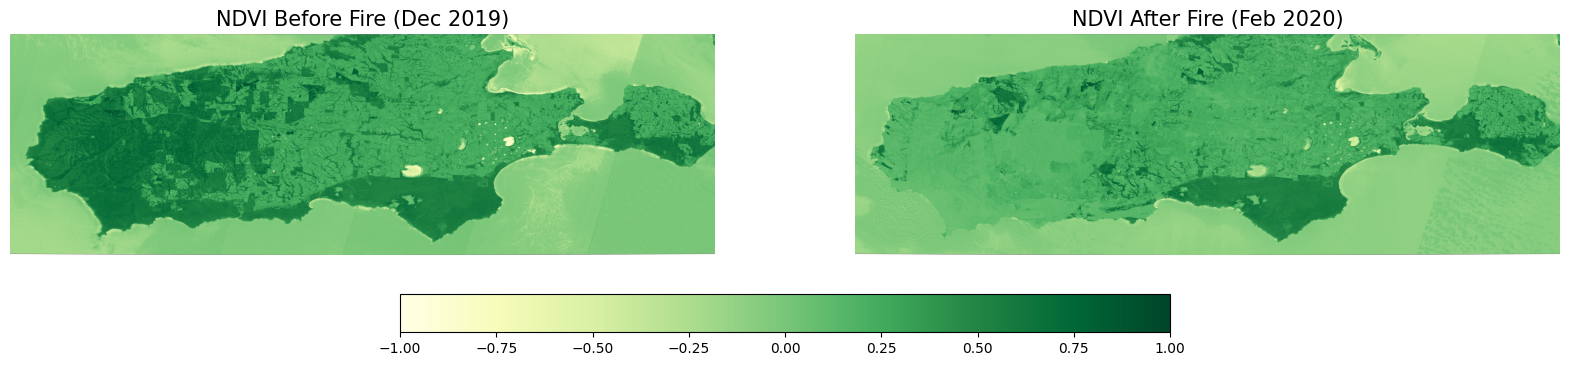

In [5]:
# Figure with two side-by-side maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the Pre-fire NDVI

im1 = ax1.imshow(pre_ndvi, cmap='YlGn', vmin=-1, vmax=1)
ax1.set_title('NDVI Before Fire (Dec 2019)', fontsize=15)
ax1.axis('off')

# Plot the Post-fire NDVI
im2 = ax2.imshow(post_ndvi, cmap='YlGn', vmin=-1, vmax=1)
ax2.set_title('NDVI After Fire (Feb 2020)', fontsize=15)
ax2.axis('off')

# add colourbar
plt.colorbar(im2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.05)

# save figure
plt.savefig(os.path.join(project_path, 'NDVI_Comparison_Figure.png'), dpi=300)
plt.show()

## Step 6: Generate Burn Severity Map

[codecarbon INFO @ 10:50:43] Energy consumed for RAM : 0.000208 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:50:43] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:50:43] Energy consumed for All CPU : 0.000885 kWh
[codecarbon INFO @ 10:50:43] 0.001094 kWh of electricity and 0.000000 L of water were used since the beginning.


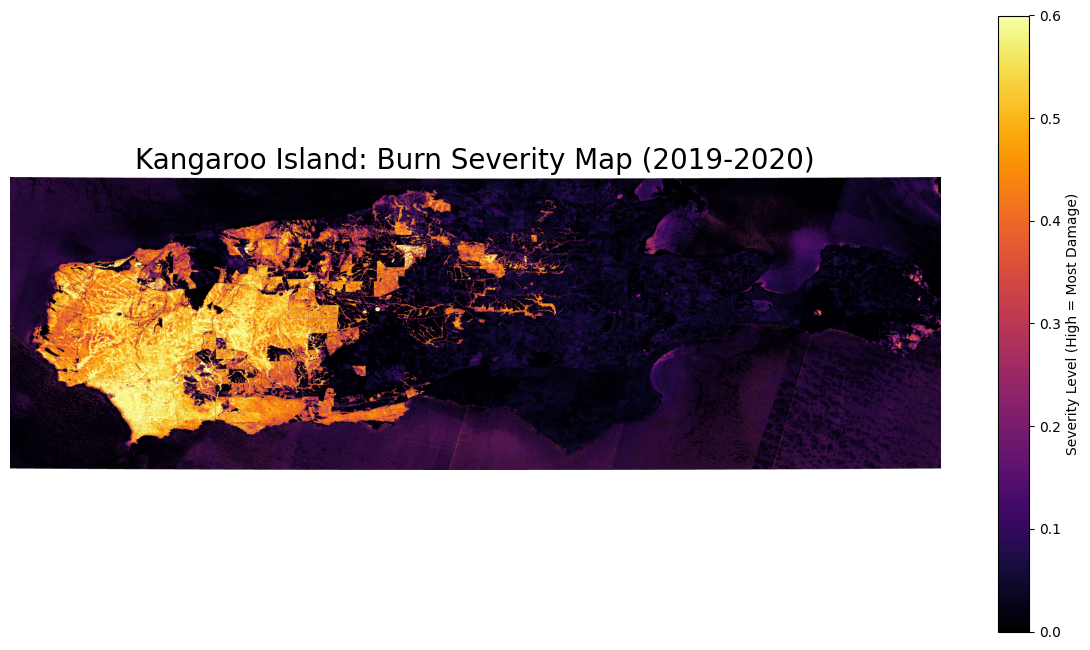

Project Insight: Approximately 4143243 pixels show high-severity burning.


In [6]:
# calculate burn severity
burn_severity = pre_ndvi - post_ndvi

# plot burn severity map
plt.figure(figsize=(15, 8))
plt.imshow(burn_severity, cmap='inferno', vmin=0, vmax=0.6)

plt.title('Kangaroo Island: Burn Severity Map (2019-2020)', fontsize=20)
plt.colorbar(label='Severity Level (High = Most Damage)')
plt.axis('off')

# save image
plt.savefig(os.path.join(project_path, 'Burn_Severity_Map.png'), bbox_inches='tight', dpi=300)
plt.show()

# check number of burned pixels (to verify whether the code worked)
burned_pixels = np.count_nonzero(burn_severity > 0.3)
print(f"Project Insight: Approximately {burned_pixels} pixels show high-severity burning.")

## Step 7: Improve Contrast against Ocean

[codecarbon INFO @ 10:51:13] Energy consumed for RAM : 0.000292 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:51:13] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:51:13] Energy consumed for All CPU : 0.001239 kWh
[codecarbon INFO @ 10:51:13] 0.001531 kWh of electricity and 0.000000 L of water were used since the beginning.


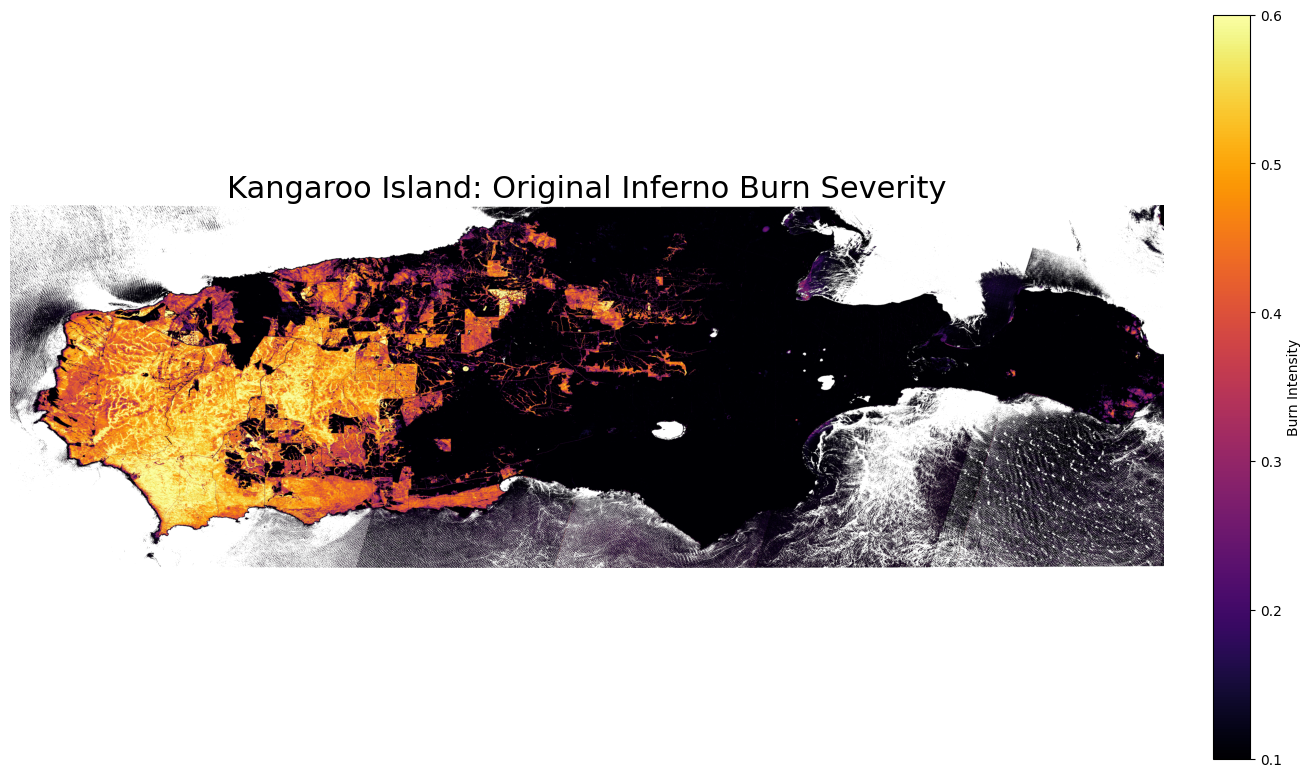

In [7]:

ocean_pixels = pre_nir < 200

# better contrast map
final_map = np.copy(burn_severity)

plt.figure(figsize=(16, 10))

# dark grey colour for sea
plt.gca().set_facecolor('#2c2c2c')

plot_data = np.where(ocean_pixels, np.nan, final_map)

# show new map
img = plt.imshow(plot_data, cmap='inferno', vmin=0.1, vmax=0.6)

plt.title('Kangaroo Island: Original Inferno Burn Severity', fontsize=22)
plt.axis('off')

plt.colorbar(img, fraction=0.03, pad=0.04, label='Burn Intensity')

# save image
plt.savefig(os.path.join(project_path, 'Kangaroo_Island_Inferno_Final.png'),
            bbox_inches='tight', dpi=300)
plt.show()


[codecarbon INFO @ 10:51:28] Energy consumed for RAM : 0.000333 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:51:28] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:51:28] Energy consumed for All CPU : 0.001416 kWh
[codecarbon INFO @ 10:51:28] 0.001750 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 10:51:28] 0.009365 g.CO2eq/s mean an estimation of 295.3406704345702 kg.CO2eq/year
[codecarbon INFO @ 10:51:43] Energy consumed for RAM : 0.000375 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:51:43] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 10:51:43] Energy consumed for All CPU : 0.001594 kWh
[codecarbon INFO @ 10:51:43] 0.001968 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 10:51:58] Energy consumed for RAM : 0.000416 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:51:58] Delta energy consumed for CPU

Success! Video saved to /content/drive/MyDrive/AI4EO/AI4EO_Main_Project/data/Fire_Analysis_Timelapse.mp4


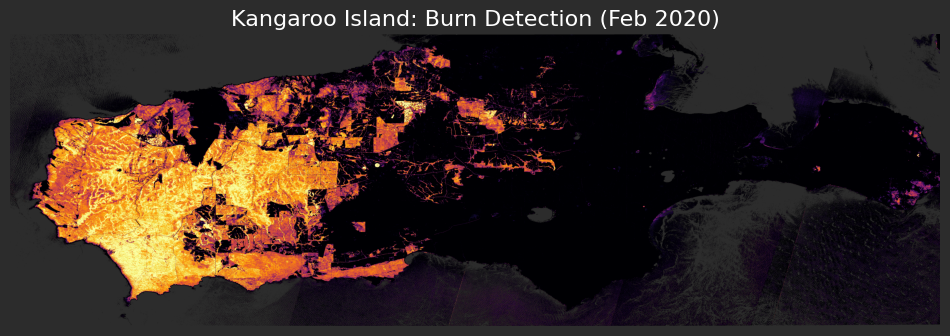

In [8]:
import matplotlib.animation as animation
from IPython.display import HTML

# this code helps recover any land pixels that were misidentified
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#2c2c2c')
ax.axis('off')

ocean_mask = pre_nir < 200
pre_plot = np.where(ocean_mask, np.nan, pre_ndvi)
post_plot = np.where(ocean_mask, np.nan, burn_severity)

im = ax.imshow(pre_plot, cmap='YlGn', vmin=-0.2, vmax=0.8)
title = ax.set_title('Kangaroo Island: Before Fire (Dec 2019)', color='white', fontsize=16)


def animate(i):
    # This creates a looping effect:
    # Frame 0-14: Healthy | Frame 15-30: Burned
    if i < 15:
        im.set_data(pre_plot)
        im.set_cmap('YlGn')
        im.set_clim(-0.2, 0.8)
        title.set_text('Kangaroo Island: Before Fire (Dec 2019)')
    else:
        im.set_data(post_plot)
        im.set_cmap('inferno')
        im.set_clim(0.1, 0.6) # Using your preferred contrast!
        title.set_text('Kangaroo Island: Burn Detection (Feb 2020)')
    return [im]

ani = animation.FuncAnimation(fig, animate, frames=30, interval=200, blit=True)

# save video
video_file = os.path.join(project_path, 'Fire_Analysis_Timelapse.mp4')
ani.save(video_file, writer='ffmpeg', fps=5)

print(f"Success! Video saved to {video_file}")



## Step 8: Generate Video comparing Pre-Fire Imagery with Burn Severity

In [9]:
from IPython.display import Video, display

# Path to the file we just made
video_path = os.path.join(project_path, 'Fire_Analysis_Timelapse.mp4')

# This will create a real video player in your notebook
display(Video(video_path, embed=True, width=700))

## Step 9: Calculate Environmental Impact of Bushfires

In [10]:
# severity threshold
burned_mask = (burn_severity > 0.3) & (~ocean_mask)

burned_pixel_count = np.sum(burned_mask)

# Calculate Impact
m2_per_pixel = 400
total_m2 = burned_pixel_count * m2_per_pixel
total_hectares = total_m2 / 10000

print(f"--- FIRE IMPACT SUMMARY ---")
print(f"High-Severity Burned Pixels: {burned_pixel_count:,}")
print(f"Total Area Destroyed: {total_hectares:,.2f} Hectares")

total_land_pixels = np.sum(~ocean_mask)
impact_percentage = (burned_pixel_count / total_land_pixels) * 100
print(f"Percentage of Island Impacted: {impact_percentage:.2f}%")

--- FIRE IMPACT SUMMARY ---
High-Severity Burned Pixels: 4,101,504
Total Area Destroyed: 164,060.16 Hectares
Percentage of Island Impacted: 23.18%


In [11]:
# save to file
stats_path = os.path.join(project_path, 'fire_statistics.txt')
with open(stats_path, 'w') as f:
    f.write(f"Total Hectares Burned: {total_hectares:.2f}\n")
    f.write(f"Percentage Burned: {impact_percentage:.2f}%\n")

In [13]:

koala_density_estimate = 1.25
tonnes_carbon_per_ha = 150
co2_conversion = 3.67

carbon_lost = total_hectares * tonnes_carbon_per_ha
co2_emitted = carbon_lost * co2_conversion

# biodiversity impact
wildlife_impact = total_hectares * koala_density_estimate
print(f"ENVIRONMENTAL ANALYSIS: ")
print(f"Total Forest Area Lost: {total_hectares:,.2f} Hectares")
print(f"Estimated CO2 Released: {co2_emitted:,.2f} Tonnes")
print(f"Estimated Wildlife Impact: ~{int(wildlife_impact):,} Koalas displaced/affected")

--- ENVIRONMENTAL ANALYSIS ---
Total Forest Area Lost: 164,060.16 Hectares
Estimated CO2 Released: 90,315,118.08 Tonnes
Estimated Wildlife Impact: ~205,075 Koalas displaced/affected


## Assess Environmental Impact for Notebook 2

In [ ]:
# 1. Stop the tracker and capture the exact emissions
# tracker.stop() returns the total kg of CO2 for this session
emissions_kg = tracker.stop()

# 2. Display the Professional Summary
print(f"      NOTEBOOK 2: FINAL ENVIRONMENTAL REPORT      ")

print(f"  - Analysis Phase: Sentinel-2 Burn Mapping")
print(f"  - Processing: 24.3 Million Pixels")
print(f"  - Visuals Generated: Inferno Maps & MP4 Timelapse")
print(f"  - Total CO2 Footprint: {emissions_kg:.6f} kg CO2")

